In [1]:
import numpy as np
import pandas as pd
from app.data.dataset.kpi_forecast import dataset

connected successfully; version PostgreSQL 17.8 (Ubuntu 17.8-1.pgdg22.04+1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0, 64-bit
connecting to nepa db
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 38902 rows
connecting to nepa db
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 373589 rows
connecting to nepa db
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 500000 rows
Loaded chunk with 437151 rows


In [2]:
df_features = dataset

# Training

## Ridge Regression
### Chosen as a Classic benchmark

In [3]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


target_col = "target_diff"
df_ridge = df_features.drop(["day_of_week", "month"], axis=1)
feature_cols = [c for c in df_ridge if "target_diff" not in c and c != "invoice_date"]




In [4]:
# cleaning
df_ridge_clean = df_ridge.dropna(subset=[target_col]+feature_cols).copy()

# df_ridge_clean = 

cutoff_date = pd.to_datetime("2026-01-20")
bad_data = pd.to_datetime("2026-04-25")


train_mask =  df_ridge_clean["invoice_date"] <= cutoff_date

test_mask = (df_ridge_clean["invoice_date"] > cutoff_date) & (
    df_ridge_clean["invoice_date"] < bad_data
)

df_ridge_clean.drop(["invoice_date"], axis=1, inplace=True)

df_ridge_clean_train = df_ridge_clean.loc[train_mask]
df_ridge_clean_test = df_ridge_clean.loc[test_mask]


In [5]:
# train test
X_train = df_ridge_clean_train[feature_cols].drop("target", axis=1)
y_train = df_ridge_clean_train[target_col]

X_test = df_ridge_clean_test[feature_cols].drop("target", axis=1)
y_test = df_ridge_clean_test[target_col]

y_actual=df_ridge_clean_test["target"]

In [6]:
# training
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.01)
)

ridge_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['revenue_signed_sum','qty_signed_sum','discount_sum',...,'rev_lag_16', 'rev_lag_22','rev_lag_29']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [7]:
# metrics 
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
y_pred = ridge_model.predict(X_test)
y_lag_1 = X_test["revenue_signed_sum"]
y_lag_7 = X_test["rev_lag_6"]
y_pred_actual = y_pred + X_test["revenue_signed_sum"]
y_test_actual = y_actual

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
mse_lag_1= mean_squared_error(y_lag_1, y_pred_actual)
mse_lag_7= mean_squared_error(y_lag_7, y_pred_actual)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_actual, y_pred_actual)
r2_lag_1 = 1 - (mse/mse_lag_1)
r2_lag_7 = 1 - (mse/mse_lag_7)

n = len(y_test_actual)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics_df = pd.DataFrame({
    "Metric": ["R² Score", "Adjusted R²", "MAE", "MSE", "RMSE", "R2_lag_1", "R2_lag_7"],
    "Value": [r2, adj_r2, mae, mse, rmse, r2_lag_1, r2_lag_7]
})

if not (y_test == 0).any():
    mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
    metrics_df.loc[len(metrics_df)] = ["MAPE", f"{mape:.2%}"]


print(metrics_df.to_string(index=False))

mean_val = y_test_actual.mean()

print(f"Average Target Value: {mean_val:,.2f}")
print(f"Relative Error (MAE / Mean): {mae / mean_val:.2%}")



KeyError: 'rev_lag_6'

In [ ]:
# feature importance
# feature_cols.pop(5)
coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": ridge_model.named_steps["ridge"].coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Top 10 Most Important Lag Features:")
print(coefficients.head(30).to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Subplot 1: Time Series Plot (Actual vs Predicted Over Time) ---
axes[0].plot(
    y_test.index, y_actual, 
    label="Actual Target", color="#1f77b4", alpha=0.75, linewidth=1.5
)
axes[0].plot(
    y_test.index, y_pred_actual, 
    label="Ridge Predicted", color="#e377c2", linestyle="--", alpha=0.9, linewidth=1.5
)
axes[0].set_title("Actual vs. Predicted Over Time", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Invoice Date", fontsize=11)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].legend(loc="upper right", fontsize=11)
axes[0].grid(True, linestyle=":", alpha=0.6)

# --- Subplot 2: Scatter Plot (Actual vs Predicted with Perfect Fit Line) ---
axes[1].scatter(
    y_actual, y_pred_actual, 
    alpha=0.4, color="#2ca02c", edgecolors="none", s=25
)

# Reference 45-degree line for perfect predictions (y = x)
min_val = min(y_actual.min(), y_pred_actual.min())
max_val = max(y_actual.max(), y_pred_actual.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = x)")

axes[1].set_title("Actual vs. Predicted Scatter Plot", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Actual Target", fontsize=11)
axes[1].set_ylabel("Predicted Value", fontsize=11)
axes[1].legend(loc="upper left", fontsize=11)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## ETS Baseline

In [ ]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

In [ ]:
# data modelling
df_ets = df_features[["invoice_date","revenue_signed_sum"]]

cutoff_date = pd.to_datetime("2026-01-20")
bad_data = pd.to_datetime("2026-04-25")

train_mask =  df_ets["invoice_date"] <= cutoff_date
test_mask = (df_ets["invoice_date"] > cutoff_date) & (
    df_ets["invoice_date"] < bad_data
)


df_ets.drop(["invoice_date"], axis=1, inplace=True)

df_ets_train = df_ets.loc[train_mask]
df_ets_test = df_ets.loc[test_mask]

In [ ]:
ets_model = ETSModel(
    df_ets_train,
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

ets_model = ets_model.fit()




## Xg boost

### Choosen as a decent Medium resource baseline

In [3]:
from xgboost import XGBRegressor

In [4]:
# cleaning
df_xgb = df_features.copy()

cutoff_date = pd.to_datetime("2025-10-19")
bad_data = pd.to_datetime("2026-04-25") # switch to month 04
target_col = ["target_diff", "target_qty_diff"]

train_mask =  df_xgb["invoice_date"] <= cutoff_date

test_mask = (df_xgb["invoice_date"] > cutoff_date) & (
    df_xgb["invoice_date"] < bad_data
)

# df_xgb.drop(["invoice_date"], axis=1, inplace=True)

df_xgb["day_of_week"] = df_xgb["day_of_week"].astype('category')
df_xgb["month"] = df_xgb["month"].astype('category')


# df_xgb.drop(test_drop, axis=1, inplace=True)

# df_xgb = df_xgb.sample(frac=1, axis=1, random_state=42)

unrequired_cols = ['target_qty_diff', 'target_diff', 'dow_tgt_enc', 'month_tgt_enc']

feature_cols = [c for c in df_xgb if c not in unrequired_cols and c != "invoice_date"]

df_xgb_train = df_xgb.loc[train_mask]
df_xgb_test = df_xgb.loc[test_mask]

In [5]:
# train test

# train test
X_train = df_xgb_train[feature_cols].drop(["target", "target_qty"], axis=1)
y_train = df_xgb_train[target_col]

X_test = df_xgb_test[feature_cols].drop(["target", "target_qty"], axis=1)
y_test = df_xgb_test[target_col]

y_actual = df_xgb_test[["target", "target_qty"]]

In [6]:
# metrics for revenue
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

def get_metrics():

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    mse_lag_1= mean_squared_error(y_lag_1, y_pred_actual)
    mse_lag_7= mean_squared_error(y_lag_7, y_pred_actual)

    rmse = np.sqrt(mse)

    # wape
    sum_actuals = np.sum(np.abs(y_test_actual))
    wape = np.sum(np.abs(y_test_actual - y_pred_actual)) / sum_actuals if sum_actuals != 0 else np.nan
    wape_naive = np.sum(np.abs(y_test_actual - y_lag_7)) / sum_actuals if sum_actuals != 0 else np.nan


    r2 = r2_score(y_test_actual, y_pred_actual)
    r2_lag_1 = 1 - (mse/mse_lag_1)
    r2_lag_7 = 1 - (mse/mse_lag_7)

    n = len(y_test_actual)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    metrics_df = pd.DataFrame({
        "Metric": ["R² Score", "Adjusted R²", "MAE", "MSE", "RMSE", "R2_lag_1", "R2_lag_7", "WAPE"],
        "Value": [f"{v:.2f}" for v in[r2, adj_r2, mae, mse, rmse, r2_lag_1, r2_lag_7, wape]]
    })

    if not (y_test["target_diff"] == 0).any():
        mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
        metrics_df.loc[len(metrics_df)] = ["MAPE", f"{mape:.2%}"]


    print(metrics_df.to_string(index=False))

    mean_val = y_test_actual.mean()

    print(f"Average Target Value: {mean_val:,.2f}")
    print(f"Relative Error (MAE / Mean): {mae / mean_val:.2%}")
    print(f"naive MAPE: {wape_naive:.2f}")


In [28]:
X_train.columns

Index(['revenue_signed_sum', 'qty_signed_sum', 'discount_sum', 'month',
       'day_of_week', 'day_of_week_sma7W', 'qty_7d_ma', 'rev_7d_ma',
       'qty_lag_7', 'qty_lag_8', 'qty_lag_9', 'qty_lag_15', 'qty_lag_16',
       'qty_lag_22', 'qty_lag_29', 'rev_lag_7', 'rev_lag_8', 'rev_lag_9',
       'rev_lag_10', 'rev_lag_15', 'rev_lag_16', 'rev_lag_22', 'rev_lag_29'],
      dtype='str')

In [66]:
# model def
xgb_model = XGBRegressor(
    n_estimators=600, # no touch
    learning_rate=0.03, # no touch
    max_depth=3, # no touch
    subsample=0.8, # no touch
    colsample_bytree=1, #no touch
    enable_categorical=True,
    random_state=42
)

# training
xgb_model.fit(
    X_train,
    y_train,
    # feature_weights=feature_weights
)

y_pred = xgb_model.predict(X_test)
y_lag_1 = X_test["revenue_signed_sum"]
y_lag_7 = X_test["rev_lag_7"]
y_sma_7 = X_test["rev_7d_ma"]
y_pred_actual = y_pred[:,0] + X_test["revenue_signed_sum"]
y_test_actual = y_actual["target"]
get_metrics()

     Metric          Value
   R² Score           0.52
Adjusted R²           0.45
        MAE      195017.99
        MSE 75605967467.85
       RMSE      274965.39
   R2_lag_1           0.64
   R2_lag_7           0.14
       WAPE           0.24
Average Target Value: 818,980.81
Relative Error (MAE / Mean): 23.81%
naive MAPE: 0.31


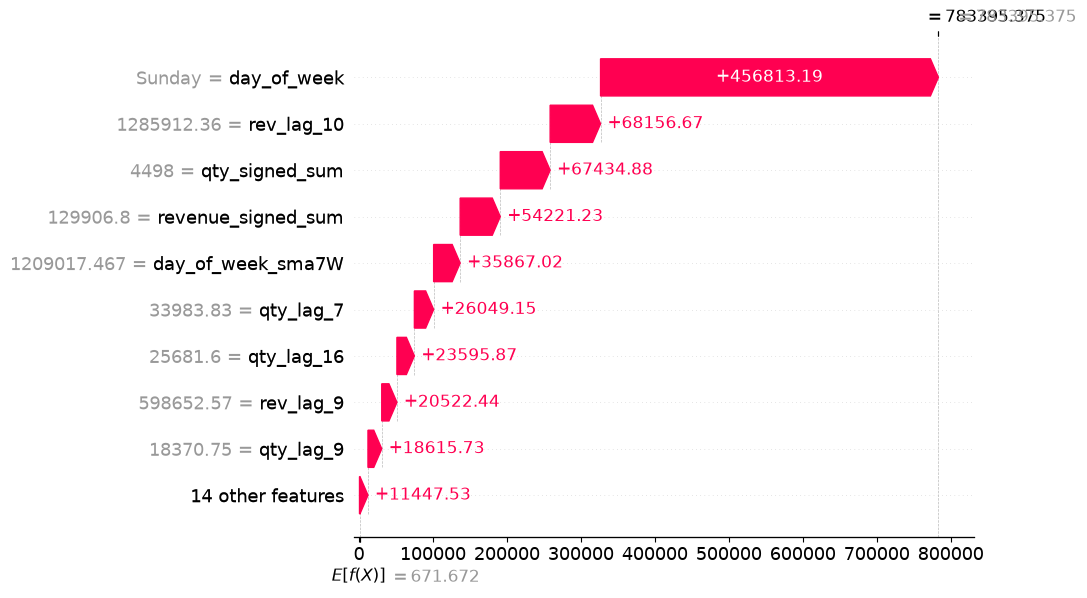

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

row_index = 90


shap.plots.waterfall(shap_values[row_index,:,0])

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


row_idx = np.arange(len(y_test))

# Create a figure with 2 subplots (stacked vertically with a 2:1 height ratio)
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[2, 1],
    subplot_titles=(
        "Actual vs. Predicted Over Time",
        "Actual vs. Predicted Scatter Plot",
    ),
    vertical_spacing=0.12,
)

# --- Subplot 1: Time Series Plot (Actual vs Predicted Over Time) ---
fig.add_trace(
    go.Scatter(
        x=y_test.index,
        y=y_test_actual,
        customdata=row_idx,
        mode="lines",
        name="Actual Target",
        line=dict(color="#1f77b4", width=1.5),
        opacity=0.75,
        hovertemplate=(
            "Row Index: %{customdata}<br>"
            "Invoice Date: %{x}<br>"
            "Actual Value: %{y:,.2f}"
            "<extra></extra>"
        ),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=y_test.index,
        y=y_pred_actual,
        customdata=row_idx,
        mode="lines",
        name="XG B",
        line=dict(color="#e377c2", width=1.5, dash="dash"),
        opacity=0.9,
        hovertemplate=(
            "Row Index: %{customdata}<br>"
            "Invoice Date: %{x}<br>"
            "Actual Value: %{y:,.2f}"
            "<extra></extra>"
        ),
    ),
    row=1,
    col=1,
)

# --- Subplot 2: Scatter Plot (Actual vs Predicted with Perfect Fit Line) ---
fig.add_trace(
    go.Scatter(
        x=y_test_actual,
        y=y_pred_actual,
        customdata=row_idx,
        mode="markers",
        marker=dict(
            color="#2ca02c",
            opacity=0.4,
            size=5,  # Equivalent to s=25 (area in matplotlib)
        ),
        showlegend=False,
        hovertemplate=(
            "Row Index: %{customdata}<br>"
            "Invoice Date: %{x}<br>"
            "Actual Value: %{y:,.2f}"
            "<extra></extra>"
        ),
    ),
    row=2,
    col=1,
)

# Reference 45-degree line for perfect predictions (y = x)
min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())

fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode="lines",
        name="Perfect Fit (y = x)",
        line=dict(color="red", width=2, dash="dash"),
    ),
    row=2,
    col=1,
)

# --- Axis Labels & Grid Formatting ---
fig.update_xaxes(
    title_text="Invoice Date",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.1)",
    row=1,
    col=1,
)
fig.update_yaxes(
    title_text="Value", showgrid=True, gridcolor="rgba(0,0,0,0.1)", row=1, col=1
)

fig.update_xaxes(
    title_text="Actual Target",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.1)",
    row=2,
    col=1,
)
fig.update_yaxes(
    title_text="Predicted Value",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.1)",
    row=2,
    col=1,
)

# Set overall layout sizing and white background style
fig.update_layout(
    height=800,
    width=1000,
    template="plotly_white",
    legend=dict(x=1.01, y=1, xanchor="left", yanchor="top"),
)

fig.show()

=== Relative Feature Importance (Gain) ===
           Feature  Importance
       day_of_week    0.214046
         qty_lag_9    0.114081
revenue_signed_sum    0.068524
 day_of_week_sma7W    0.062182
        rev_lag_10    0.060625
         rev_lag_9    0.054631
         rev_7d_ma    0.049169
    qty_signed_sum    0.042648
         qty_lag_7    0.042332
         qty_7d_ma    0.039558
        rev_lag_16    0.031925
        qty_lag_29    0.031638
        qty_lag_16    0.030072
        qty_lag_22    0.028977
        rev_lag_29    0.028072
         rev_lag_7    0.025816
             month    0.014807
      discount_sum    0.013987
        rev_lag_22    0.013504
         rev_lag_8    0.011609
        qty_lag_15    0.010904
        rev_lag_15    0.006529
         qty_lag_8    0.004363

=== Detailed XGBoost Metrics Breakdown ===
           Feature  Gain (Loss Reduction)  Weight (Split Count)  Cover (Sample Coverage)
       day_of_week           3.132624e+12                 194.0               41

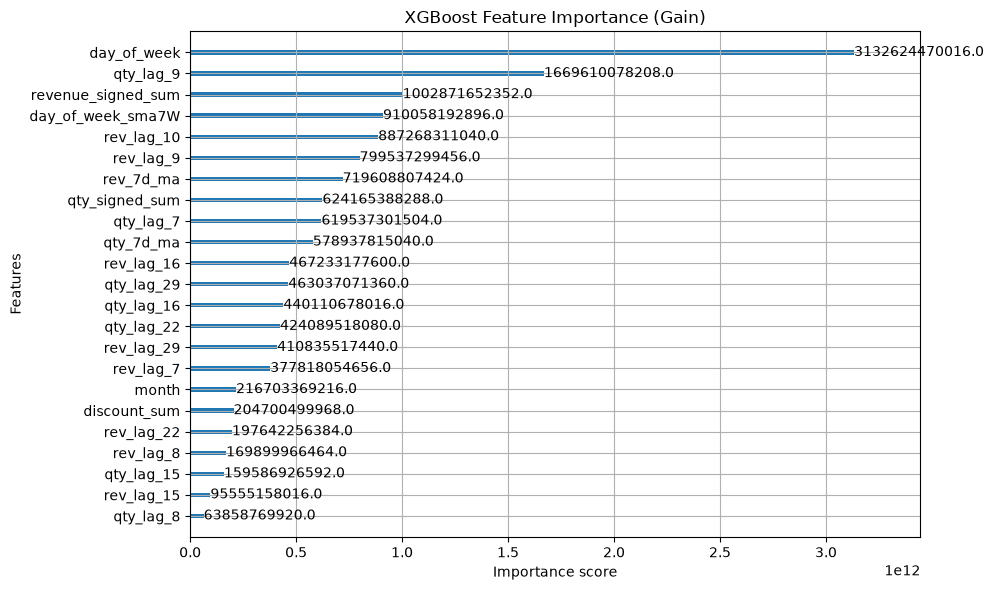

In [17]:
# feature importances
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. Standard Scikit-Learn API Importances (Normalized Gain)
# Works if X_train was a DataFrame or using feature_cols list
features = getattr(xgb_model, "feature_names_in_", feature_cols)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("=== Relative Feature Importance (Gain) ===")
print(importance_df.to_string(index=False))


# 2. Detailed XGBoost Breakdown (Gain, Weight/Frequency, Cover)
booster = xgb_model.get_booster()

# Map internal feature names (f0, f1...) to actual column names if needed
feature_map = {f"f{i}": col for i, col in enumerate(features)}

def get_mapped_score(importance_type):
    score = booster.get_score(importance_type=importance_type)
    return {feature_map.get(k, k): v for k, v in score.items()}

gain_scores = get_mapped_score("gain")      # Avg loss reduction per split
weight_scores = get_mapped_score("weight")  # Number of times feature was split on
cover_scores = get_mapped_score("cover")    # Avg samples affected by splits

detailed_df = pd.DataFrame({
    "Feature": features,
    "Gain (Loss Reduction)": [gain_scores.get(f, 0.0) for f in features],
    "Weight (Split Count)": [weight_scores.get(f, 0) for f in features],
    "Cover (Sample Coverage)": [cover_scores.get(f, 0.0) for f in features]
}).sort_values(by="Gain (Loss Reduction)", ascending=False)

print("\n=== Detailed XGBoost Metrics Breakdown ===")
print(detailed_df.to_string(index=False))


# 3. Visual Plot
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type="gain", ax=ax, title="XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

In [ ]:
# metrics for quantity
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
y_pred = xgb_model.predict(X_test)
y_lag_1 = X_test["qty_signed_sum"]
y_lag_7 = X_test["qty_lag_7"]
y_pred_actual = y_pred[:,1] + X_test["qty_signed_sum"]
y_test_actual = y_actual["target_qty"]

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
mse_lag_1= mean_squared_error(y_lag_1, y_pred_actual)
# mse_lag_7= mean_squared_error(y_lag_7, y_pred_actual)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_actual, y_pred_actual)
r2_lag_1 = 1 - (mse/mse_lag_1)
# r2_lag_7 = 1 - (mse/mse_lag_7)

n = len(y_test_actual)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics_df = pd.DataFrame({
    "Metric": ["R² Score", "Adjusted R²", "MAE", "MSE", "RMSE", "R2_lag_1"],
    "Value": [r2, adj_r2, mae, mse, rmse, r2_lag_1]
})

if not (y_test["target_diff"] == 0).any():
    mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
    metrics_df.loc[len(metrics_df)] = ["MAPE", f"{mape:.2%}"]


print(metrics_df.to_string(index=False))

mean_val = y_test_actual.mean()

print(f"Average Target Value: {mean_val:,.2f}")
print(f"Relative Error (MAE / Mean): {mae / mean_val:.2%}")



In [ ]:
# plot for revenue
import matplotlib.pyplot as plt

# Create a figure with 2 subplots (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Subplot 1: Time Series Plot (Actual vs Predicted Over Time) ---
axes[0].plot(
    y_test.index, y_actual["target_qty"], 
    label="Actual Target", color="#1f77b4", alpha=0.75, linewidth=1.5
)
axes[0].plot(
    y_test.index, y_pred_actual, 
    label="XG B", color="#e377c2", linestyle="--", alpha=0.9, linewidth=1.5
)
# axes[0].plot(
#     y_test.index, y_lag_7, 
#     label="Naive lag7", color="#a52e06", linestyle="-.", alpha=0.9, linewidth=1.5
# )
axes[0].set_title("Actual vs. Predicted Over Time", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Invoice Date", fontsize=11)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].legend(loc="upper right", fontsize=11)
axes[0].grid(True, linestyle=":", alpha=0.6)

# --- Subplot 2: Scatter Plot (Actual vs Predicted with Perfect Fit Line) ---
axes[1].scatter(
    y_actual["target_qty"], y_pred_actual, 
    alpha=0.4, color="#2ca02c", edgecolors="none", s=25
)

# Reference 45-degree line for perfect predictions (y = x)
min_val = min(y_actual["target_qty"].min(), y_pred_actual.min())
max_val = max(y_actual["target_qty"].max(), y_pred_actual.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = x)")

axes[1].set_title("Actual vs. Predicted Scatter Plot", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Actual Target", fontsize=11)
axes[1].set_ylabel("Predicted Value", fontsize=11)
axes[1].legend(loc="upper left", fontsize=11)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [67]:
# Rolling backtest harness

# 1. Ensure datetime type and sort by date
df_xgb_test['invoice_date'] = pd.to_datetime(df_xgb_test['invoice_date'])
df_xgb_test = df_xgb_test.sort_index()

min_date = df_xgb_test['invoice_date'].min()
max_date = df_xgb_test['invoice_date'].max()


if min_date.weekday() == 6:  #sunday 
    first_full_week_start = min_date.normalize()
else:
    first_full_week_start = (min_date + pd.offsets.Week(weekday=6)).normalize()


if max_date.weekday() == 5:  # saturday
    last_full_week_end = max_date
else:
    last_full_week_end = (max_date - pd.offsets.Week(weekday=5)).replace(
        hour=23, minute=59, second=59
    )

df_backtest = df_xgb_test[
    (df_xgb_test['invoice_date'] >= first_full_week_start)
    & (df_xgb_test['invoice_date'] <= last_full_week_end)
].copy()

X_btest = df_backtest[feature_cols].drop(["target", "target_qty"], axis=1)
y_btest = df_backtest[target_col]

def wape(tgt, pred):
    sum_actuals = np.sum(np.abs(tgt))
    wape_val = np.sum(np.abs(tgt - pred)) / sum_actuals if sum_actuals != 0 else np.nan
    return wape_val
    


In [69]:
test_week_starts = pd.date_range(
    start = first_full_week_start,
    end=last_full_week_end-pd.Timedelta(days=6),
    freq="7D"
)
rev_score = 0 # to calc how many slices the model was better than naive
qty_score = 0
week_num = 0
for week_start in test_week_starts:
    week_end = week_start +pd.Timedelta(days=27) # set slice window
    if week_start == pd.Timestamp('2026-04-12'):
        week_end = week_start +pd.Timedelta(days=6) # set slice window
    week_num+= 1
    hist = pd.DataFrame(df_xgb.loc[:week_start,[ # to get historical data for rolling bt
        'revenue_signed_sum', 'qty_signed_sum', 'discount_sum', 'month',
        'day_of_week', 'day_of_week_sma7W',
        'qty_7d_ma', 'rev_7d_ma', 'qty_lag_7', 'qty_lag_8', 'qty_lag_9',
        'qty_lag_15', 'qty_lag_16', 'qty_lag_22', 'qty_lag_29', 'rev_lag_7',
        'rev_lag_8', 'rev_lag_9', 'rev_lag_10', 'rev_lag_15', 'rev_lag_16',
        'rev_lag_22', 'rev_lag_29'
    ]])
    pred_hist = pd.DataFrame()

    for date in pd.date_range(week_start,week_end, freq="D"):
        
        row_act = df_xgb.loc[[date], feature_cols].drop(columns=["target_qty", "target"])
        if date == week_start:
            row = row_act
        # print(date)
        y_pred = xgb_model.predict(row)
        
        y_pred_actual_rev = y_pred[0,0] + row.loc[date,"revenue_signed_sum"]
        y_pred_actual_qty = y_pred[0,1] + row.loc[date,"qty_signed_sum"]
        
        target = df_xgb.loc[date, "target"]
        target_qty = df_xgb.loc[date, "target_qty"]

        pred = pd.DataFrame(
            [{
                'invoice_date': date,
                'y_pred_rev': y_pred_actual_rev,
                'y_pred_qty': y_pred_actual_qty,
                'target': target,
                'target_qty': target_qty,
                "rev_naive": hist.loc[date-pd.Timedelta(days=6), "revenue_signed_sum"],
                "qty_naive": hist.loc[date-pd.Timedelta(days=6), "qty_signed_sum"]
            }],
            index = [date]
        )
        pred_hist = pd.concat([pred_hist,pred])

        if week_start != pd.Timestamp('2026-04-12') or date != week_end:
            row = pd.DataFrame([{
                "revenue_signed_sum": y_pred_actual_rev,
                "qty_signed_sum": y_pred_actual_qty,
                "discount_sum": hist.loc[week_start-pd.Timedelta(days=1), "discount_sum"],
                "month": pd.Categorical([(date+pd.Timedelta(days=1)).month], categories=X_train["month"].cat.categories)[0],
                "day_of_week": pd.Categorical([(date+pd.Timedelta(days=1)).day_name()], categories=X_train["day_of_week"].cat.categories)[0],
                "day_of_week_sma7W": hist.loc[hist.index.dayofweek == (date+pd.Timedelta(days=1)).dayofweek,"revenue_signed_sum"].tail(7).sum()/7,
                'qty_7d_ma': hist.loc[date-pd.Timedelta(days=6):date, "qty_signed_sum"].sum()/7,
                'rev_7d_ma': hist.loc[date-pd.Timedelta(days=6):date, "revenue_signed_sum"].sum()/7,
                'qty_lag_7': hist.loc[date-pd.Timedelta(days=6), "qty_signed_sum"],
                'qty_lag_8': hist.loc[date-pd.Timedelta(days=7), "qty_signed_sum"],
                'qty_lag_9': hist.loc[date-pd.Timedelta(days=8), "qty_signed_sum"],
                'qty_lag_15': hist.loc[date-pd.Timedelta(days=14), "qty_signed_sum"],
                'qty_lag_16': hist.loc[date-pd.Timedelta(days=15), "qty_signed_sum"],
                'qty_lag_22': hist.loc[date-pd.Timedelta(days=21), "qty_signed_sum"],
                'qty_lag_29': hist.loc[date-pd.Timedelta(days=28), "qty_signed_sum"],
                'rev_lag_7': hist.loc[date-pd.Timedelta(days=6), "revenue_signed_sum"],
                'rev_lag_8': hist.loc[date-pd.Timedelta(days=7), "revenue_signed_sum"],
                'rev_lag_9': hist.loc[date-pd.Timedelta(days=8), "revenue_signed_sum"],
                'rev_lag_10': hist.loc[date-pd.Timedelta(days=9), "revenue_signed_sum"],
                'rev_lag_15': hist.loc[date-pd.Timedelta(days=14), "revenue_signed_sum"],
                'rev_lag_16': hist.loc[date-pd.Timedelta(days=15), "revenue_signed_sum"],
                'rev_lag_22': hist.loc[date-pd.Timedelta(days=21), "revenue_signed_sum"],
                'rev_lag_29': hist.loc[date-pd.Timedelta(days=28), "revenue_signed_sum"]
            }], index = [date+pd.Timedelta(days=1)]
            ).astype({
                'month': 'category',
                'day_of_week': 'category'
            })
        hist = pd.concat([hist,row])
    # retrain model on new data
    train_window = df_xgb.loc[:week_start+pd.Timedelta(days=6)]
    xgb_model.fit(
        train_window[feature_cols].drop(["target", "target_qty"], axis=1),
        train_window[target_col]
    )

    #wape calc
    wape_btest_rev = wape(pred_hist['target'], pred_hist['y_pred_rev'])
    n_wape_btest_rev = wape(pred_hist['target'], pred_hist["rev_naive"])

    if wape_btest_rev < n_wape_btest_rev:
        rev_score += 1

    wape_btest_qty = wape(pred_hist['target_qty'], pred_hist['y_pred_qty'])
    n_wape_btest_qty = wape(pred_hist['target_qty'], pred_hist["qty_naive"])
    if wape_btest_qty < n_wape_btest_qty:
        qty_score += 1

    # print(f'rev wape: {wape_btest_rev}')
    # print(f'qty wape: {wape_btest_qty}')

print(week_num)
print((f"for week: {week_start} to {week_end}"))
print((f"rev pred by model is better than naive t-7 in {rev_score/week_num} of slices"))
print((f"qty pred by model is better than naive t-7 in {qty_score/week_num} of slices"))

25
for week: 2026-04-12 00:00:00 to 2026-04-18 00:00:00
rev pred by model is better than naive t-7 in 0.52 of slices
qty pred by model is better than naive t-7 in 0.56 of slices


In [31]:
df_xgb.columns

Index(['revenue_signed_sum', 'qty_signed_sum', 'discount_sum', 'target',
       'target_diff', 'target_qty', 'target_qty_diff', 'invoice_date', 'month',
       'day_of_week', 'month_tgt_enc', 'dow_tgt_enc', 'day_of_week_sma7W',
       'qty_7d_ma', 'rev_7d_ma', 'qty_lag_7', 'qty_lag_8', 'qty_lag_9',
       'qty_lag_15', 'qty_lag_16', 'qty_lag_22', 'qty_lag_29', 'rev_lag_7',
       'rev_lag_8', 'rev_lag_9', 'rev_lag_10', 'rev_lag_15', 'rev_lag_16',
       'rev_lag_22', 'rev_lag_29'],
      dtype='str')